**Experiment 6: Implement a Logistic Regression algorithm for binary classification using Python Programming.**

**Aim:** To implement and evaluate a Logistic Regression model for binary classification using the Haberman Survival Dataset and analyze model performance through hyperparameter tuning and evaluation metrics.

**Overview of Logistic Regression**

**Logistic Regression** is a **supervised machine learning algorithm used for binary classification problems**.
It predicts the **probability that a given input belongs to a particular class** using a logistic (sigmoid) function.

Unlike linear regression, logistic regression outputs **probabilities between 0 and 1**, which are then used to assign class labels.

---

**Key Formulas (Plain Text for Colab)**

**Linear Model**

z = β0 + β1x1 + β2x2 + ... + βnxn

---

**Sigmoid (Logistic) Function**

p = 1 / (1 + e^(-z))

or

p = 1 / (1 + e^(-(β0 + β1x1 + β2x2 + ... + βnxn)))

---

**Prediction Rule**

If p ≥ 0.5 → Class = 1
If p < 0.5 → Class = 0

---

**Log-Odds (Logit Function)**

log(p / (1 - p)) = β0 + β1x1 + β2x2 + ... + βnxn

---

**Loss Function (Log Loss / Cross Entropy)**

Loss = -(1/N) * Σ [ y log(p) + (1 - y) log(1 - p) ]

---

**Key Terms**

**1. Dependent Variable (Target)**
The output variable being predicted (binary class: 0 or 1).

**2. Independent Variables (Features)**
Input variables used to predict the target.

**3. Sigmoid Function**
A function that converts linear output into probability between 0 and 1.

**4. Odds**
Odds = p / (1 - p)

Represents the ratio of probability of success to failure.

**5. Log-Odds (Logit)**
The logarithm of odds used to create a linear relationship with features.

**6. Coefficients (β)**
Parameters that represent the influence of each feature on the prediction.

**7. Decision Boundary**
A threshold (usually 0.5) used to classify probabilities into classes.

**8. Maximum Likelihood Estimation (MLE)**
A method used to estimate model parameters by maximizing the likelihood of observed data.


**Mount Drive (Google Colab)**

In [39]:
from google.colab import drive

drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


**Dataset Loading and Inspection**

In [40]:
import pandas as pd

survival_data = pd.read_csv('drive/My Drive/Datasets For ML/Haberman Survival.csv')

print("Columns:", survival_data.columns)
print("\nShape:", survival_data.shape)
print("\nDuplicated:", survival_data.duplicated().sum())
print("\nNull Values:", survival_data.isnull().sum().sum())
print("\nFirst 2 Rows:")
survival_data.head(2)

Columns: Index(['Age', 'Operation_Year', 'Positive_Nodes', 'Survival_Status'], dtype='object')

Shape: (306, 4)

Duplicated: 17

Null Values: 0

First 2 Rows:


,Age,Operation_Year,Positive_Nodes,Survival_Status
0,30,64,1,1
1,30,62,3,1


**Data Preprocessing**

**Remove Duplicates**

In [41]:
survival_data = survival_data.drop_duplicates()
print("After Removing Duplicates:")
print("Duplicated:", survival_data.duplicated().sum())
print("Shape:", survival_data.shape)

After Removing Duplicates:
Duplicated: 0
Shape: (289, 4)


**Feature–Label Separation**

In [42]:
X, Y = survival_data.iloc[:, :-1], survival_data.iloc[:, -1]

In [43]:
print("Features:\n", X.head(3))
print("\nTarget:\n", Y.head(3))

Features:
    Age  Operation_Year  Positive_Nodes
0   30              64               1
1   30              62               3
2   30              65               0

Target:
 0    1
1    1
2    1
Name: Survival_Status, dtype: int64


**Class & Feature Distributions**

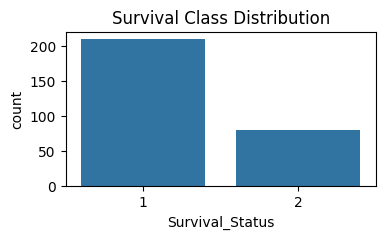

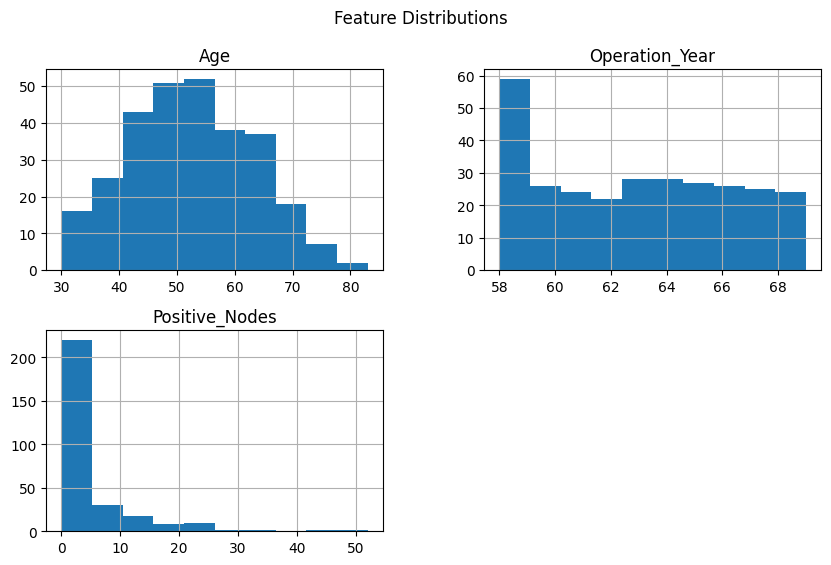

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class balance
plt.figure(figsize=(4,2))
sns.countplot(x=Y)
plt.title("Survival Class Distribution")
plt.show()

# Check feature distributions
X.hist(figsize=(10,6))
plt.suptitle("Feature Distributions")
plt.show()

**Observation:**

1. If the classes are imbalanced, logistic regression may be biased toward the majority class.

2. Feature scaling is usually helpful for logistic regression, especially if we use L1/L2 penalties.

**Feature Scaling**

Since features have different scales (e.g., age vs number of nodes), we standardize them:

In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
X_scaled[:10]

array([[0.        , 0.54545455, 0.01923077],
       [0.        , 0.36363636, 0.05769231],
       [0.        , 0.63636364, 0.        ],
       [0.01886792, 0.09090909, 0.03846154],
       [0.01886792, 0.63636364, 0.07692308],
       [0.05660377, 0.        , 0.19230769],
       [0.05660377, 0.18181818, 0.        ],
       [0.0754717 , 0.09090909, 0.        ],
       [0.0754717 , 0.72727273, 0.17307692],
       [0.0754717 , 0.        , 0.57692308]])

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size = 0.3, random_state = 42, stratify =  Y)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (202, 3)
Test Shape: (87, 3)


**Logistic Regression Model**

**1. Manual Hyperparameter Tuning**

We'll vary C (regularization strength) and penalty (l1 vs l2) and plot train and test accuracies.

In [48]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Candidate hyperparameters
C_values = [0.01, 0.1, 1, 10, 100]
penalties = ['l1', 'l2']

train_scores = np.zeros((len(penalties), len(C_values)))
test_scores = np.zeros((len(penalties), len(C_values)))

for i, p in enumerate(penalties):
    for j, C in enumerate(C_values):
        model = LogisticRegression(
            C=C,
            penalty=p,
            solver='liblinear',  # liblinear supports l1/l2
            class_weight='balanced',  # handle class imbalance
            max_iter=500,
            random_state=42
        )
        model.fit(X_train, Y_train)
        train_scores[i, j] = model.score(X_train, Y_train)
        test_scores[i, j] = model.score(X_test, Y_test)

**2. Plotting Train/Test Accuracy**

**How to interpret the plot:**

Look for high test accuracy with a small gap between train and test → best generalization.

If train >> test → overfitting.

If train ≈ test ≈ low → underfitting.

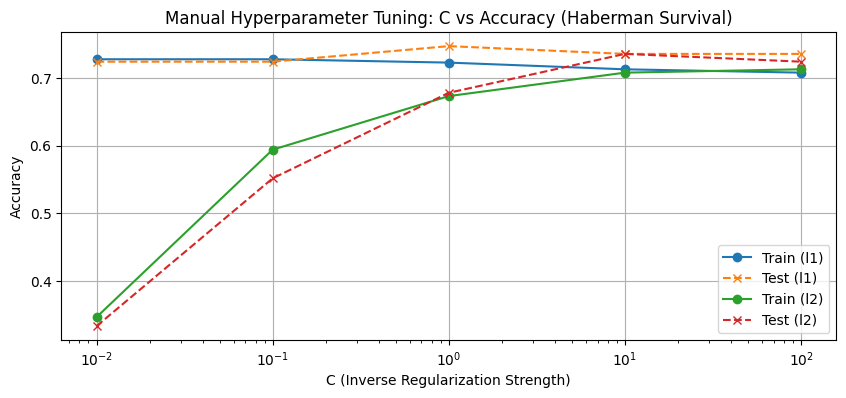

In [49]:
plt.figure(figsize=(10,4))

for i, p in enumerate(penalties):
    plt.plot(C_values, train_scores[i], marker='o', label=f'Train ({p})')
    plt.plot(C_values, test_scores[i], marker='x', linestyle='--', label=f'Test ({p})')

plt.xscale('log')
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Manual Hyperparameter Tuning: C vs Accuracy (Haberman Survival)")
plt.legend()
plt.grid(True)
plt.show()

**3. Selecting the Best Hyperparameters**

In [50]:
# Find best test accuracy
best_idx = np.unravel_index(test_scores.argmax(), test_scores.shape)
best_penalty = penalties[best_idx[0]]
best_C = C_values[best_idx[1]]

print(f"Best Test Accuracy: {test_scores[best_idx]:.4f}")
print(f"Optimal Penalty: {best_penalty}")
print(f"Optimal C: {best_C}")

Best Test Accuracy: 0.7471
Optimal Penalty: l1
Optimal C: 1


**4. Train Final Optimized Model**

In [51]:
best_model = LogisticRegression(
    C=best_C,
    penalty=best_penalty,
    solver='liblinear',
    class_weight='balanced',
    max_iter=500,
    random_state=42
)
best_model.fit(X_train, Y_train)

Y_pred = best_model.predict(X_test)

**Model Evaluation**

In [52]:
from sklearn import metrics

print("Accuracy:", metrics.accuracy_score(Y_test, Y_pred))
print("Classification Report:\n", metrics.classification_report(Y_test, Y_pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(Y_test, Y_pred))

Accuracy: 0.7471264367816092
Classification Report:
               precision    recall  f1-score   support

           1       0.80      0.87      0.83        63
           2       0.56      0.42      0.48        24

    accuracy                           0.75        87
   macro avg       0.68      0.64      0.65        87
weighted avg       0.73      0.75      0.73        87

Confusion Matrix:
 [[55  8]
 [14 10]]


**Visualization in 2D**

For 2 features, the boundary is literally a straight line:


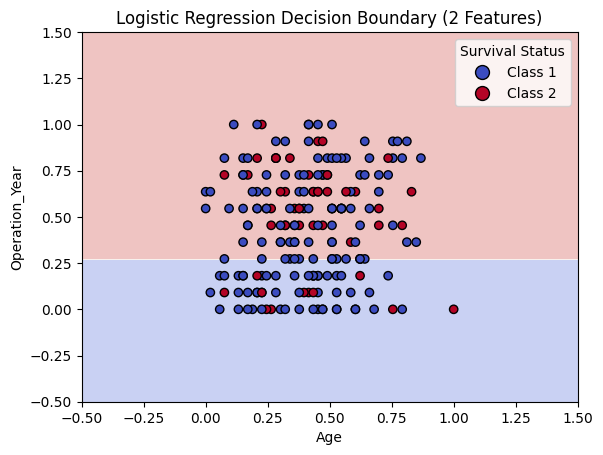

In [53]:
# Pick two features for 2D visualization
X_vis, Y_vis = X_train[:, :2], Y_train # first two features

# Get actual feature names
feature_names = X.columns[:2].tolist()

# Fit logistic regression on 2 features
model_2d = LogisticRegression(C=best_C, penalty=best_penalty, solver='liblinear', class_weight='balanced', max_iter=500)
model_2d.fit(X_vis, Y_vis)

# Plot decision boundary
x_min, x_max = X_vis[:, 0].min()-0.5, X_vis[:, 0].max()+0.5
y_min, y_max = X_vis[:, 1].min()-0.5, X_vis[:, 1].max()+0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot data points with legend
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=Y_vis, cmap=plt.cm.coolwarm, edgecolor='k')

# Create legend for the scatter plot
# Get unique classes and map them to colors for the legend
classes = np.unique(Y_vis)
handles = [plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=scatter.cmap(scatter.norm(cls)), markersize=10, label=f'Class {cls}') for cls in classes]
plt.legend(handles=handles, title="Survival Status")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Logistic Regression Decision Boundary (2 Features)")
plt.show()

**Conclusion**

The decision boundary produced by logistic regression is a straight line that separates Class 1 and Class 2. Logistic regression can model only linear boundaries in a two-feature space, so it cannot form curves or complex shapes. When the data points from different classes overlap and are not linearly separable, some samples will inevitably be misclassified.

